In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/walmart.csv")
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)
print(df["Date"].min(), "to", df["Date"].max(), "|", df["Date"].nunique(), "weeks")

Matplotlib is building the font cache; this may take a moment.


2010-02-05 00:00:00 to 2012-10-26 00:00:00 | 143 weeks


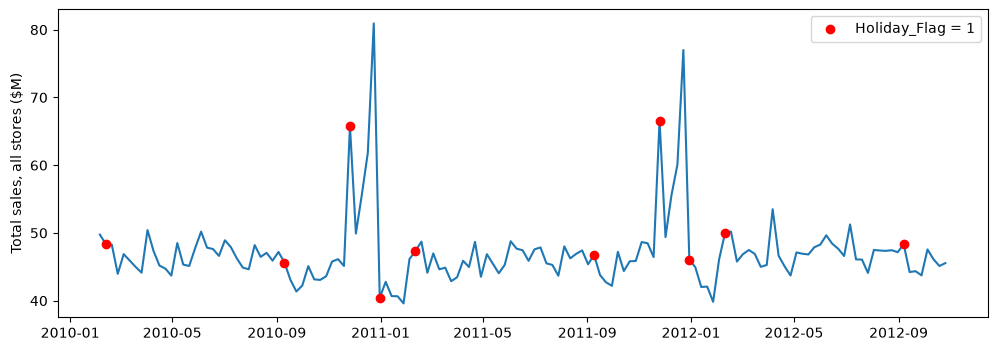

In [ ]:
# Total Sales over time & Holiday weeks marked

weekly = df.groupby("Date").agg(sales=("Weekly_Sales", "sum"), holiday=("Holiday_Flag", "max"))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly.index, weekly["sales"] / 1e6)
hol = weekly[weekly["holiday"] == 1]
ax.scatter(hol.index, hol["sales"] / 1e6, color="red", zorder=3, label="Holiday_Flag = 1")
ax.set_ylabel("Total sales, all stores ($M)"); ax.legend(); plt.show()

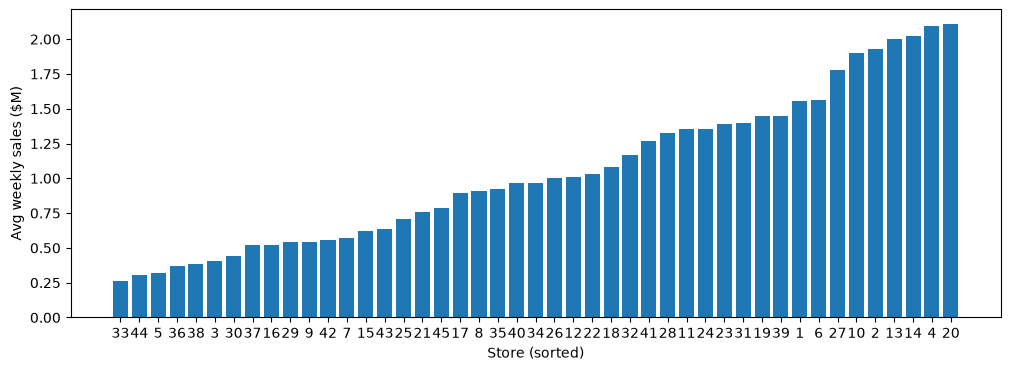

Share of sales variance explained by store alone: 91.7%


In [3]:
# how different are the stores?

store_means = df.groupby("Store")["Weekly_Sales"].mean().sort_values()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(store_means.index.astype(str), store_means / 1e6)
ax.set_xlabel("Store (sorted)"); ax.set_ylabel("Avg weekly sales ($M)"); plt.show()

within = df["Weekly_Sales"] - df.groupby("Store")["Weekly_Sales"].transform("mean")
print(f"Share of sales variance explained by store alone: {1 - within.var() / df['Weekly_Sales'].var():.1%}")

In [4]:
# Do the external factors matter overall or within a store?

factors = ["Temperature", "Fuel_Price", "CPI", "Unemployment", "Holiday_Flag"]
cols = factors + ["Weekly_Sales"]
overall = df[factors].corrwith(df["Weekly_Sales"])
demeaned = df[cols] - df.groupby("Store")[cols].transform("mean")
within_store = demeaned[factors].corrwith(demeaned["Weekly_Sales"])
print(pd.DataFrame({"overall": overall, "within_store": within_store}).round(3))

              overall  within_store
Temperature    -0.064        -0.104
Fuel_Price      0.009        -0.042
CPI            -0.073         0.019
Unemployment   -0.106        -0.050
Holiday_Flag    0.037         0.128


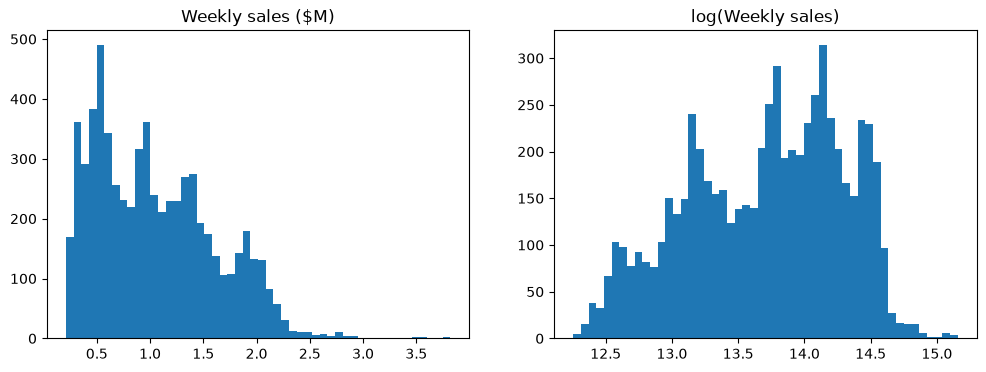

In [5]:
# Shape of the target:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Weekly_Sales"] / 1e6, bins=50); axes[0].set_title("Weekly sales ($M)")
axes[1].hist(np.log(df["Weekly_Sales"]), bins=50); axes[1].set_title("log(Weekly sales)")
plt.show()